In [13]:
# === Notebook path and directory configuration ===
from pathlib import Path
import sys

CWD = Path.cwd().resolve()
if CWD.name == "diagnostic":
    DIAGNOSTIC_DIR = CWD
elif (CWD / "diagnostic").is_dir():
    DIAGNOSTIC_DIR = CWD / "diagnostic"
else:
    DIAGNOSTIC_DIR = next((p for p in [CWD, *CWD.parents] if p.name == "diagnostic"), CWD.parent)

if str(DIAGNOSTIC_DIR) not in sys.path:
    sys.path.insert(0, str(DIAGNOSTIC_DIR))

model_outpath = Path("/compyfs/zhan391/v3_dart_cda_scratch")
dart_outpath = model_outpath

DIAG_OUT_DIR = Path("/compyfs/www/zhan391/e3sm_dart/diag_out")
DIAG_DATA_DIR = DIAG_OUT_DIR / "data"
DIAG_FIGURE_DIR = DIAG_OUT_DIR / "figure"

DIAG_DATA_DIR.mkdir(parents=True, exist_ok=True)
DIAG_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

import os
import warnings
import logging
from collections import defaultdict
from typing import Tuple, List, Dict, Optional

# === Numerical and Data Tools ===
import numpy as np
import numpy.ma as ma
import pandas as pd
import xarray as xr
import xcdat as xc
import xskillscore as xs

from datetime import datetime

# === Plotting ===
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
from matplotlib.patches import Polygon
from matplotlib import ticker
from matplotlib.ticker import FuncFormatter
from matplotlib.cm import get_cmap

# === Mapping and Projections ===
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker


from util.dart_obs_diag import (
    DartObsDiagReader
)

from util.dask_helpers import configure_dask, persist_if_dask

# === Suppress warnings globally ===
warnings.filterwarnings("ignore")

In [14]:
from configs.analysis_da_experiment_config import extract_obs_diag_config

# User setup: edit this dictionary when experiment names, runs, aliases, periods,
# or diagnostic sets change. The shared helper only validates and builds paths.
USER_EXPERIMENTS = {
    "CAM80-S0": {
        "run": "f.e21.FHIST_BGC.f09_025.CAM6assim.011",
        "key": "dart_en80",
        "alias": "CAM6EN80",
        "period": "2011120100-2012010100",
    },
    "CAM80-S1": {
        "run": "f.e22.FHIST_BGC.f09_025.CAM6assim.011",
        "key": "dart_en80",
        "alias": "CAM6EN80S1",
        "period": "2012050100-2012060100",
    },
    "CTRL10-S0": {
        "run": "CTRLEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en10",
        "alias": "CTRLEN10",
        "period": "2011120100-2012010100",
    },
    "DART10-S0": {
        "run": "DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en10",
        "alias": "DARTEN10",
        "period": "2011120100-2012010100",
    },
    "DART20-S0": {
        "run": "DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en20",
        "alias": "DARTEN20",
        "period": "2011120100-2012010100",
    },
    "DART40INF0p6-S0": {
        "run": "DARTEN40_INF0p6_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en40",
        "alias": "DARTEN40",
        "period": "2011120100-2012010100",
    },
    "DART40-S0": {
        "run": "DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en40",
        "alias": "DARTEN40",
        "period": "2011120100-2012010100",
    },
    "DART40-S1": {
        "run": "DARTEN40S1_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en40",
        "alias": "DARTEN40S1",
        "period": "2012050100-2012060100",
    },
}

# User setup: change this tuple when the available diagnostic sets change.
USER_DIAG_SETS = ("obs_seq", "obs_diag", "obs_common", "closest_member", "cam6_common")

# Optional layer for temporary add/update/remove changes. Set an experiment to None
# here to remove it without touching USER_EXPERIMENTS.
USER_EXPERIMENT_OVERRIDES = {}


def extract_exp_info(exp_name: str = None) -> dict:
    return extract_obs_diag_config(
        exp_name=exp_name,
        experiments=USER_EXPERIMENTS,
        data_path=dart_outpath,
        diag_sets=USER_DIAG_SETS,
        experiment_overrides=USER_EXPERIMENT_OVERRIDES,
    )

In [15]:
class ObsDiagPlotter:
    def __init__(
        self, var, var_dict, data_dict, fig_path,
        plevstr, region = None, regnam=None
    ):
        self.var = var
        self.var_dict = var_dict or {}
        self.data_dict = data_dict or {}
        self.fig_path = fig_path
        self.plevstr = plevstr or []
        self.region = region
        self.regnam = regnam
        self._prepare_common()

    def _prepare_common(self):
        self.cmap = {
            'blue': '#377eb8', 'orange': '#ff7f00', 'green': '#4daf4a',
            'pink': '#f781bf', 'brown': '#a65628', 'purple': '#984ea3',
            'gray': '#999999', 'red': '#e41a1c', 'yellow': '#dede00'
        }

    def _set_axes_limits(self, ax, xlim=None, ylim=None, yticks=None, xticks=None):
        if xlim is not None: ax.set_xlim(*xlim)
        if ylim is not None: ax.set_ylim(*ylim)
        if yticks is not None: ax.set_yticks(yticks)
        if xticks is not None: ax.set_xticks(xticks)

    # NEW: robust getter for inner var-config
    def _varcfg(self):
        """Return inner var-config whether var_dict is an inner dict or a single-entry wrapper."""
        vd = self.var_dict
        if isinstance(vd, dict) and 'y1aix' in vd:
            return vd
        if isinstance(vd, dict) and len(vd) == 1:
            return next(iter(vd.values()))
        raise ValueError(
            "var_dict not recognized. Pass inner dict with keys like 'y1aix'/'y2aix', "
            "or a single-entry wrapper {var_key: inner}."
        )

    def check_flat_lev_consistency(self, lev_dict):
        ref_var = next(iter(lev_dict))
        reference = lev_dict[ref_var]
        for var, lev in lev_dict.items():
            if lev != reference:
                raise ValueError(
                    f"Inconsistent pressure level list for variable '{var}'.\n"
                    f"Expected: {reference}\nFound:    {lev}"
                )
        print("All level lists are consistent across variables.")
        return reference
    
    def build_ts_var_dict(
        self, var_key: str = None, name: str = None,
        y1axis: list = None, y2axis: list = None
    ) -> dict:
        var_key = var_key or 'RADIOSONDE_U'
        name = name or 'RADIOSONDE_U_WIND_COMPONENT'
        entry = {
            'name': name,
            'lev_type': 'pressure',
            'CopySpread': 'totalspread',
            'CopyRMSE': 'rmse',
            'CopyNposs': 'Nposs',
            'CopyNused': 'Nused',
            'type1': 'guess',
            'type2': 'VPguess',
            'type3': 'guess_RankHist',
            'y1aix': y1axis if y1axis is not None else [0, 10],
            'y2aix': [0, 100],
            'y1aix0': y2axis if y2axis is not None else [0, 10],
            'y2aix0': [0, 100],
        }
        return {var_key: entry}
    
    def compute_experiment_means(
        self,
        data_dict,
        diagnostic_keys_to_average,
        diagnostic_keys_to_sum=None,
        persist=False,
    ):
        diagnostic_keys_to_sum = diagnostic_keys_to_sum or []
        sample_var_data = next(iter(data_dict.values()))
        experiments = list(sample_var_data.keys())
        all_diagnostic_keys = set()
        for var_data in data_dict.values():
            for exp_data in var_data.values():
                all_diagnostic_keys.update(exp_data.keys())
        all_diagnostic_keys.update(diagnostic_keys_to_average)
        all_diagnostic_keys.update(diagnostic_keys_to_sum)
        mean_dict = {}
        for exp in experiments:
            mean_dict[exp] = {}
            for key in all_diagnostic_keys:
                if key in diagnostic_keys_to_average or key in diagnostic_keys_to_sum:
                    valid_data = []
                    for var in data_dict:
                        entry = data_dict[var].get(exp, {}).get(key, None)
                        if entry is None or not hasattr(entry, "size") or entry.size == 0:
                            continue
                        valid_data.append(entry)
                    if valid_data:
                        try:
                            if any(isinstance(arr, xr.DataArray) for arr in valid_data):
                                valid_data = [
                                    arr if isinstance(arr, xr.DataArray) else xr.DataArray(arr)
                                    for arr in valid_data
                                ]
                                stacked = xr.concat(valid_data, dim="obs_type")
                                if key in diagnostic_keys_to_sum:
                                    metric_array = stacked.sum(dim="obs_type", skipna=True)
                                else:
                                    metric_array = stacked.mean(dim="obs_type", skipna=True)
                                metric_array = persist_if_dask(metric_array, persist)
                            else:
                                stacked = np.stack(valid_data, axis=0)
                                if key in diagnostic_keys_to_sum:
                                    metric_array = np.nansum(stacked, axis=0)
                                else:
                                    metric_array = np.nanmean(stacked, axis=0)
                        except ValueError:
                            shapes = [arr.shape for arr in valid_data]
                            print(f"[WARN] Shape mismatch for '{key}' in '{exp}': {shapes}. Skipping metric.")
                            metric_array = None
                    else:
                        metric_array = None
                    mean_dict[exp][key] = metric_array
                else:
                    values = [
                        data_dict[var][exp][key]
                        for var in data_dict
                        if exp in data_dict[var] and key in data_dict[var][exp]
                    ]
                    if not values:
                        mean_dict[exp][key] = None
                        continue
                    first_val = values[0]
                    if all(np.array_equal(np.asarray(first_val), np.asarray(v)) for v in values):
                        mean_dict[exp][key] = first_val
                    else:
                        raise ValueError(
                            f"Inconsistent values for diagnostic key '{key}' in experiment '{exp}'."
                        )
        return mean_dict
    
    def _auto_ylims(self, values, *, pad_frac=0.25, symmetric=False):
        """
        Compute nice y-limits from a 1D array-like metric.

        Parameters
        ----------
        values : array-like
            Metric values (nan-safe).
        pad_frac : float
            Fractional padding on each side (default 0.10 = 10%).
        symmetric : bool
            If True, make y-limits symmetric around zero.
        """
        import numpy as np

        arr = np.asarray(values, dtype=float)
        arr = arr[np.isfinite(arr)]
        if arr.size == 0:
            return (-1, 1)  # fallback

        vmin, vmax = arr.min(), arr.max()

        # If all values identical → pad around that value
        if np.isclose(vmin, vmax):
            delta = abs(vmin) * pad_frac if vmin != 0 else 1.0
            return (vmin - delta, vmax + delta)

        if symmetric:
            bound = max(abs(vmin), abs(vmax))
            pad = bound * pad_frac
            return (-bound - pad, bound + pad)

        # Regular: padded min/max
        pad = (vmax - vmin) * pad_frac
        return (vmin - pad, vmax + pad)

    def plot_metric_by_experiment(
            self,
            plev_subset,
            metrics,
            metric_dict,
            xmin,
            xmax,
            xunit,
            fontz,
            dpi,
            panel_width,
            panel_height,
            show,
            save,
            fig_idx=0,
            shared_legend=True, 
        ):
        """
        Generate one figure with one row per experiment and one column per metric.
        The first column is RMSE and the second column is Spread/RMSE when those
        metrics are passed in that order.
        """

        exp_names = list(self.data_dict.keys())
        nrows = len(exp_names)
        ncols = len(metrics)

        if ncols == 0:
            raise ValueError("At least one metric is required for plotting.")

        tableau = [
            "#4e79a7", "#f28e2b", "#e15759", "#76b7b2",
            "#59a14f", "#edc948", "#b07aa1", "#ff9da7"
        ]

        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=(panel_width * ncols, panel_height),
            sharex=True,
            squeeze=False,
        )

        legend_handles = None
        legend_labels = None

        for i, exp in enumerate(exp_names):
            d = self.data_dict[exp]
            time = np.asarray(d["time"])
            mask = (time >= xmin) & (time <= xmax)
            time_f = time[mask]

            for j, metric in enumerate(metrics):
                ax = axes[i, j]

                if metric not in d or d[metric] is None:
                    ax.text(
                        0.5,
                        0.5,
                        f"{metric} not available\nrerun the reader/class cells",
                        transform=ax.transAxes,
                        ha="center",
                        va="center",
                        fontsize=fontz * 0.9,
                    )
                    ax.set_axis_off()
                    continue

                if metric == "spread":
                    low, high = metric_dict["spread"]["reliability_band"]
                    ax.axhspan(low, high, color="grey", alpha=0.25, zorder=0)
                    ax.axhline(1.0, color="k", linestyle="--", lw=1.2, zorder=1)

                for il, lev in enumerate(plev_subset):
                    color = tableau[il % len(tableau)]

                    if metric == "spread":
                        if isinstance(d["spread"], xr.DataArray) or isinstance(d["rmse"], xr.DataArray):
                            spread = d["spread"].clip(min=1e-4)
                            rmse = d["rmse"].clip(min=1e-4)
                        else:
                            spread = np.clip(np.asarray(d["spread"]), 1e-4, None)
                            rmse = np.clip(np.asarray(d["rmse"]), 1e-4, None)
                        values = spread / rmse
                    elif metric == "rmse":
                        values = d["rmse"]
                    else:
                        values = d[metric]

                    if values.ndim != 2:
                        raise ValueError("Metric array must be time x level.")
                    if lev not in self.plevstr:
                        print(f"[WARN] Requested level '{lev}' not found in lev_str; skipping.")
                        continue

                    ilev = self.plevstr.index(lev)
                    if isinstance(values, xr.DataArray):
                        vals = values.isel({values.dims[0]: mask, values.dims[1]: ilev}).compute().values
                    else:
                        vals = np.asarray(values)[mask, ilev]
                    ax.plot(
                        time_f,
                        vals,
                        label=lev.replace(" ", ""),
                        color=color,
                        lw=2.0,
                        alpha=0.9,
                    )

                cfg = metric_dict[metric]
                if cfg.get("ylim") is not None:
                    ax.set_ylim(cfg["ylim"])
                if cfg.get("yscale"):
                    ax.set_yscale(cfg["yscale"])
                ax.set_ylabel(cfg["unit"], fontsize=fontz)
                ax.tick_params(labelsize=fontz * 0.95)

                panel_letter = chr(97 + i * ncols + j + fig_idx)
                ax.set_title(
                    f"({panel_letter}) {exp} ({self.var})",
                    fontsize=fontz * 1.01,
                    pad=8,
                    loc="left",
                )
                ax.set_title(
                    cfg["name"],
                    fontsize=fontz * 1.01,
                    pad=8,
                    loc="right",
                )

                if i == nrows - 1:
                    ax.set_xlabel(f"Days since {xunit}", fontsize=fontz)

                if not shared_legend:
                    ax.legend(fontsize=fontz * 0.95, ncol=2)
                elif legend_handles is None:
                    legend_handles, legend_labels = ax.get_legend_handles_labels()

        if shared_legend and legend_handles:
            fig.legend(
                legend_handles,
                legend_labels,
                loc="lower center",
                ncol=max(1, len(legend_labels) // 2 + 1),
                fontsize=fontz * 0.95,
                frameon=True,
                bbox_to_anchor=(0.5, -0.03),
            )

        fig.tight_layout()
        if show:
            plt.show()
        if save:
            metric_tag = "_".join(metrics)
            fname = os.path.join(
                self.fig_path,
                f"fig_metric_{metric_tag}_{self.var}_{self.region}.pdf",
            )
            fig.savefig(fname, dpi=dpi, bbox_inches="tight")
            plt.close(fig)


Found match for variable Temperature in Conventional: TEMPERATURE
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/CTRLEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en10/dart_diagnostics/obs_diag/CTRLEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011120100-2012010100.nc
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en10/dart_diagnostics/obs_diag/DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011120100-2012010100.nc
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en20/dart_diagnostics/obs_diag/DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011120100-2012010100.nc
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en40/dart_diagnostics/obs_diag/DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.da

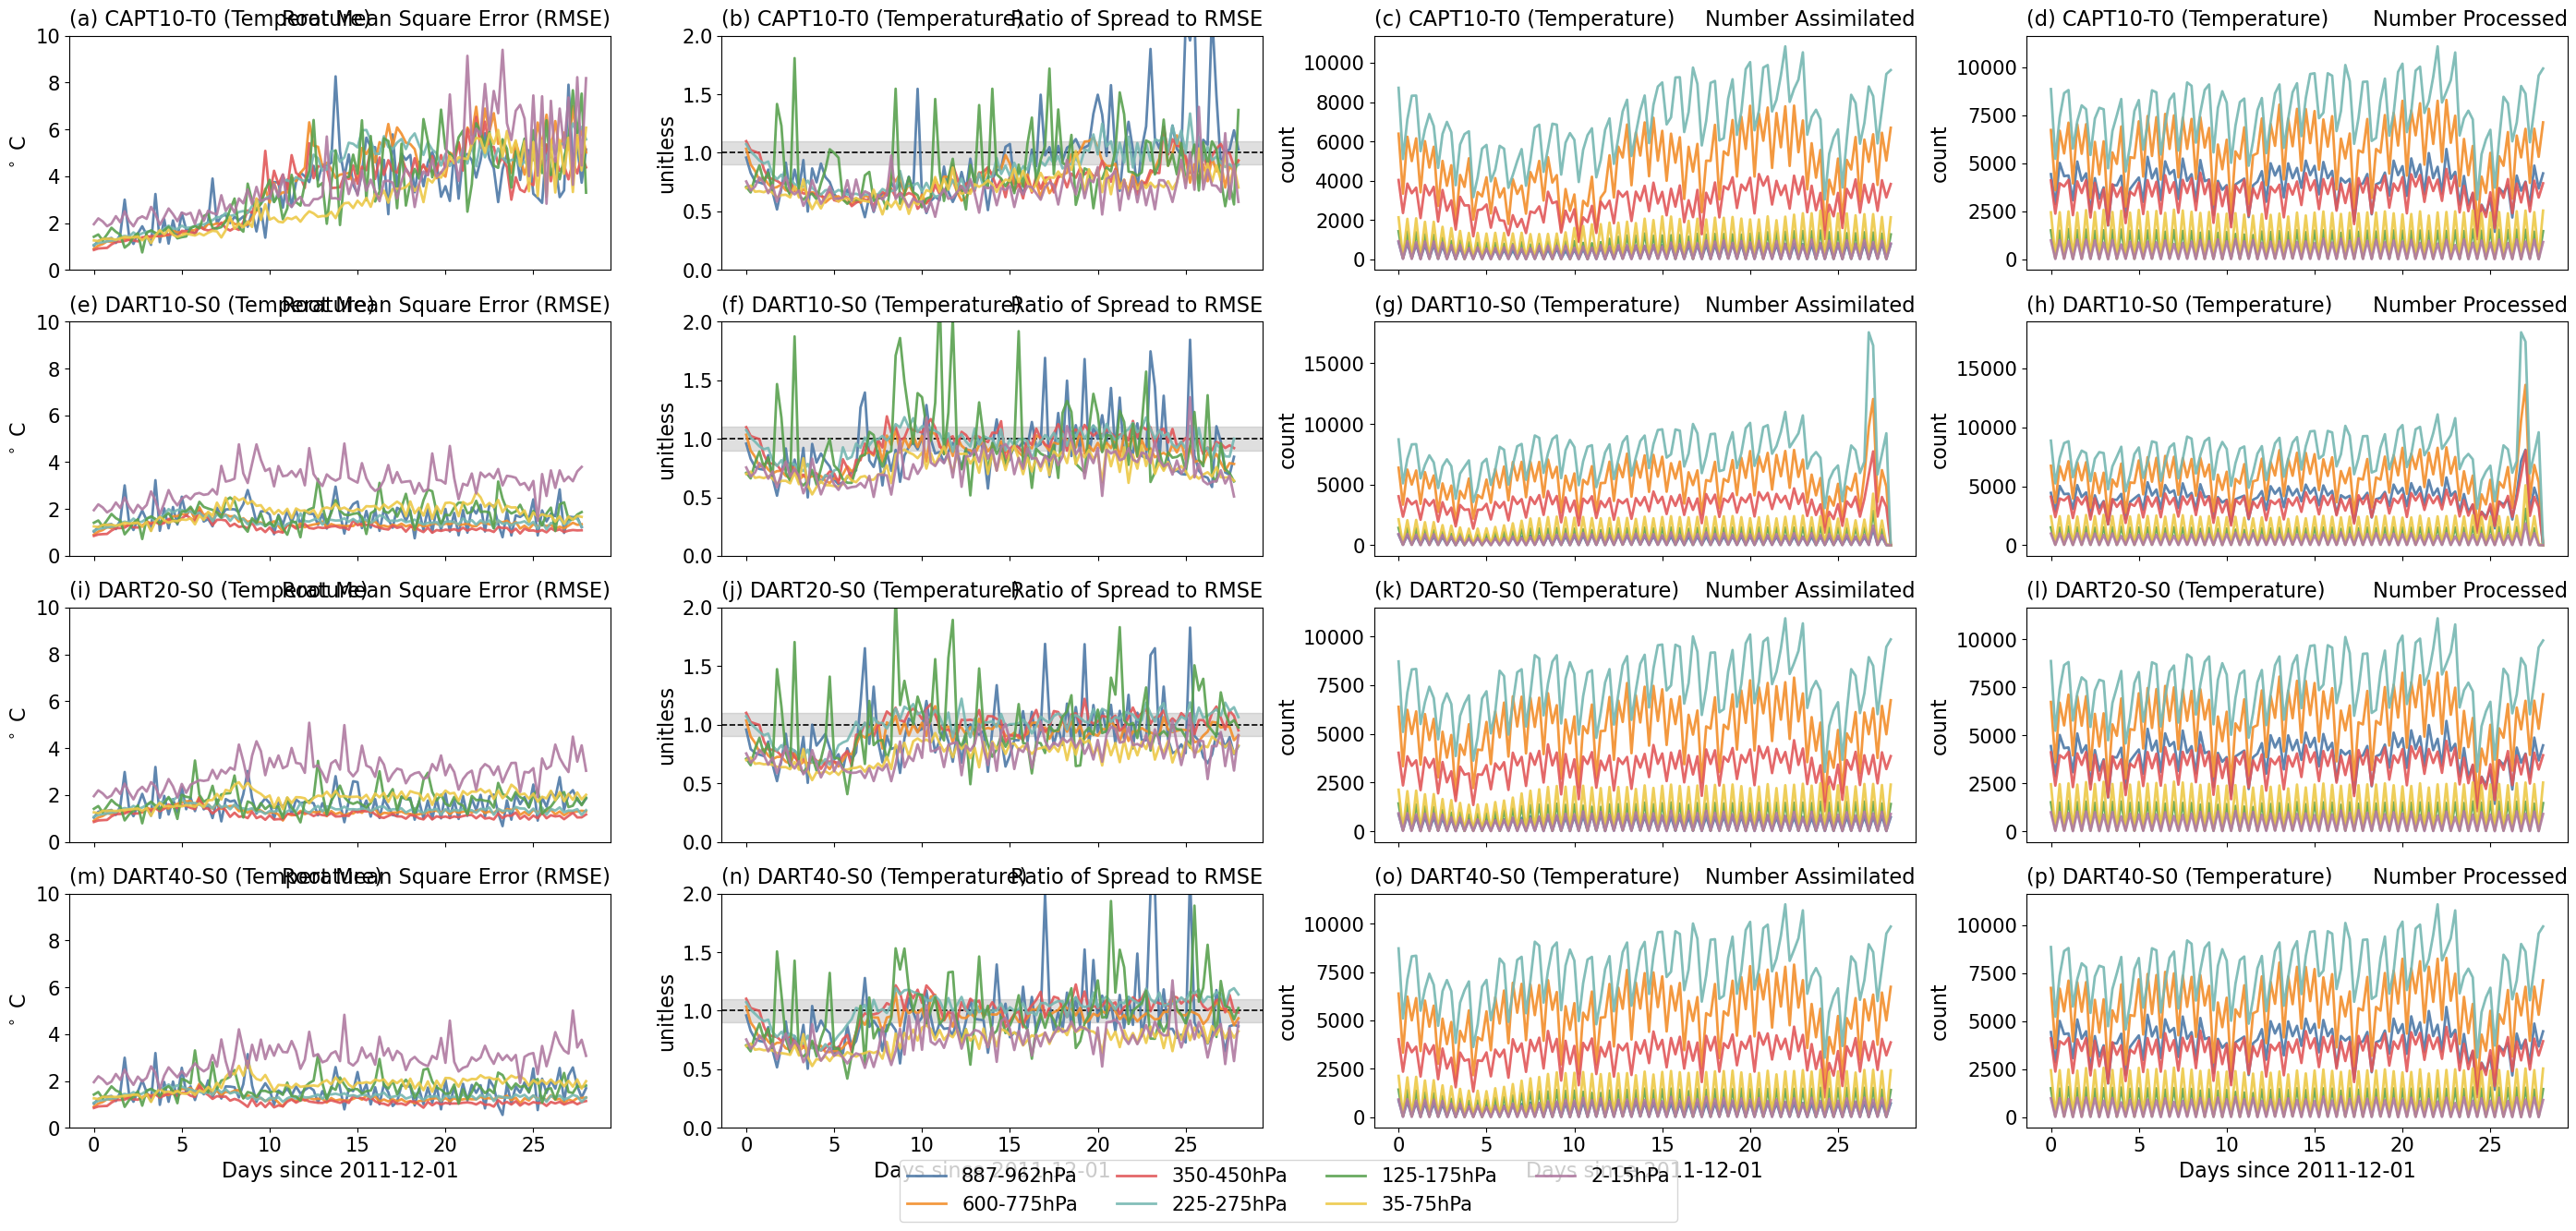

In [16]:
def plot_obs_diag_variable(
    varstr="Temperature",
    *,
    region="NH",
    plot_levs=None,
    exps=None,
    labels=None,
    diag_set="diag2",
    dtype="guess",
    tunit="2011-12-01",
    xmin=0,
    xmax=28,
    show=True,
    save=True,
    panel_width=7,
    panel_height=13,
    fontz=16,
    dpi=600,
    use_dask=True,
    dask_chunks=None,
    persist_means=False,
):
    # Source roots: model_outpath, dart_outpath (configured above)
    from importlib import reload
    import util.dart_obs_diag as dart_obs_diag_module

    reader_cls = reload(dart_obs_diag_module).DartObsDiagReader
    fig_path = str(DIAG_FIGURE_DIR / "analysis_da" / "obs_diagnostics" / "time_series")
    Path(fig_path).mkdir(parents=True, exist_ok=True)
    dask_client = configure_dask(use_distributed=False) if use_dask else None
    dask_chunks = dask_chunks or {"time": 31, "copy": -1, "plevel": -1, "region": 1}

    variable_settings = {
        "U_WIND": {
            "unit": "m s$^{-1}$",
            "rmse_ylim": (0, 25),
            "vbound": ([1, 7], [0, 18]),
        },
        "V_WIND": {
            "unit": "m s$^{-1}$",
            "rmse_ylim": (0, 25),
            "vbound": ([1, 7], [0, 18]),
        },
        "Temperature": {
            "unit": "$^\\circ$ C",
            "rmse_ylim": (0, 10),
            "vbound": ([1, 7], [0, 18]),
        },
        "Humidity": {
            "unit": "kg kg$^{-1}$",
            "rmse_ylim": (0, 0.004),
            "vbound": ([0, 0.004], [0, 18]),
        },
    }
    if varstr not in variable_settings:
        options = ", ".join(variable_settings)
        raise ValueError(f"Unsupported varstr='{varstr}'. Choose one of: {options}")

    settings = variable_settings[varstr]
    varunt = settings["unit"]
    vbound = settings["vbound"]
    varlev = "plevel"

    exp_info = extract_exp_info()
    exp_cfg = dict(exp_info["global"])
    if use_dask:
        exp_cfg.update({
            "dask_chunks": dask_chunks,
            "return_dask": True,
            "persist_arrays": False,
        })
    exps = exps or ["CTRL10-S0", "DART10-S0", "DART20-S0", "DART40-S0"]
    labels = labels or ["CAPT10-T0", "DART10-S0", "DART20-S0", "DART40-S0"]
    exp_dict = {
        label: exp_info["experiments"][exp_tgt]
        for exp_tgt, label in zip(exps, labels)
    }
    reg_dict = {
        "NH": "Northern Hemisphere",
        "SH": "Southern Hemisphere",
        "Tropics": "Tropics",
        "NA": "North America",
        "Global": "global",
    }
    regnam = reg_dict.get(region, region)

    metric_dict = {
        "rmse": {
            "name": "Root Mean Square Error (RMSE)",
            "unit": varunt,
            "pad_frac": 0.05,
            "ylim": settings["rmse_ylim"],
        },
        "spread": {
            "name": "Ratio of Spread to RMSE",
            "unit": "unitless",
            "pad_frac": 0.25,
            "ylim": (0, 2.0),
            "reliability_band": (0.9, 1.1),
        },
        "nused": {
            "name": "Number Assimilated",
            "unit": "count",
            "pad_frac": 0.05,
            "ylim": None,
        },
        "npos": {
            "name": "Number Processed",
            "unit": "count",
            "pad_frac": 0.05,
            "ylim": None,
        },
    }
    metrics = ["rmse", "spread", "nused", "npos"]
    metrics_to_average = ["rmse", "spread"]
    metrics_to_sum = ["nused", "npos"]

    reader = reader_cls(exp_cfg)
    all_obs = reader.extract_obs_group()
    matches = [
        (group, lev, vv)
        for group, levels in all_obs.items()
        if "Satellite" not in group
        for lev, variables in levels.items()
        if varlev.lower() in lev.lower()
        for vv in variables
        if varstr.lower() in vv.lower()
    ]
    if not matches:
        raise RuntimeError(
            f"No matches for var='{varstr}' at level like '{varlev}' "
            f"(excluding Satellite). Check your obs groups."
        )

    data_dict = {}
    lev_dict = {}
    for vgroup, vlev, vname in matches:
        print(f"Found match for variable {varstr} in {vgroup}: {vname}")
        var_cfg = reader.build_ts_var_dict(varstr, name=vname)
        dat, levs = reader.extract_metrics_data(
            var=varstr,
            var_dict=var_cfg[varstr],
            dtype=dtype,
            regnam=regnam,
            diag_set=diag_set,
            exp_dict=exp_dict,
        )
        data_dict[vname] = dat
        lev_dict[vname] = levs

    plotter = ObsDiagPlotter(
        var=None,
        var_dict=None,
        data_dict=None,
        plevstr=None,
        region=region,
        regnam=regnam,
        fig_path=fig_path,
    )

    lev_str = plotter.check_flat_lev_consistency(lev_dict)
    if not lev_str:
        raise RuntimeError("Pressure levels inconsistent across variables; cannot proceed.")

    for vdata in data_dict.values():
        for exp_data in vdata.values():
            exp_data.pop("rejection", None)

    data_dict_mean = plotter.compute_experiment_means(
        data_dict,
        metrics_to_average,
        diagnostic_keys_to_sum=metrics_to_sum,
        persist=persist_means,
    )
    missing_metrics = sorted(
        metric for metric in metrics
        if any(metric not in exp_data or exp_data[metric] is None for exp_data in data_dict_mean.values())
    )
    if missing_metrics:
        print(
            "[WARN] Missing metrics after extraction: "
            + ", ".join(missing_metrics)
            + ". Re-run the setup/class cells if this notebook kernel has stale definitions."
        )
    var_dict = plotter.build_ts_var_dict(
        varstr,
        name=varstr,
        y1axis=vbound[0],
        y2axis=vbound[1],
    )

    plotter.var = varstr
    plotter.var_dict = var_dict
    plotter.data_dict = data_dict_mean
    plotter.plevstr = lev_str

    if plot_levs is None:
        plot_levs = lev_str[1::2]
    else:
        plot_levs = [lev for lev in plot_levs if lev in lev_str]
    if not plot_levs:
        raise RuntimeError("No requested pressure levels are available to plot.")

    plotter.plot_metric_by_experiment(
        plev_subset=plot_levs,
        metrics=metrics,
        metric_dict=metric_dict,
        xmin=xmin,
        xmax=xmax,
        xunit=tunit,
        fontz=fontz,
        dpi=dpi,
        panel_width=panel_width,
        panel_height=panel_height,
        show=show,
        save=save,
    )


# Select one of: "U_WIND", "V_WIND", "Temperature", "Humidity"
SELECTED_VARIABLE = "Temperature"
plot_obs_diag_variable(
    SELECTED_VARIABLE,
    use_dask=True,
    dask_chunks={"time": 31, "copy": -1, "plevel": -1, "region": 1},
    persist_means=False,
)
